# ROPAgen Document Evaluation
## LLM-as-Judge (Reference-Free Quality)

This notebook is the **third evaluation layer** for the thesis. It uses an LLM as an automated judge to assess the quality of ROPA documents generated by study participants — not by comparing them to a reference text, but by asking the model directly whether each document is legally sound and matches the scenario.

### Where this fits

| Layer | Folder | What it measures |
|---|---|---|
| 1. User survey | `python/survey/` | Subjective usability (SUS), cognitive load (NASA-TLX), confidence, mode preferences |
| 2. NLP metrics | `python/metrics/` | Lexical / semantic **similarity** between each generated ROPA and a single expert-written reference (BLEU, ROUGE, METEOR, BERTScore, SBERT) |
| **3. LLM-as-judge (this notebook)** | `python/judge/` | **Reference-free quality** — each document judged directly against the scenario and Art. 30 GDPR requirements |

### Why a third layer?

NLP metrics answer "how similar is this document to a single expert reference?" That is useful but indirect: a document can be legally sound yet score low on BLEU because it uses different wording, or it can mimic the reference surface while missing required Art. 30 elements. By asking an LLM judge to grade each document against the **task** — the scenario and GDPR requirements — we get a quality signal that is independent of any reference text.

---

### Pipeline overview (5 steps)

**1. Setup**
Resolve paths, load the 113 ROPA documents, the scenario text, and the prompt configuration from disk.

**2. Sample run**
Initialise the OpenRouter API client and run the judge on one document per mode (Form, Ask, Chat) as a sanity check. Inspect the raw output to verify the rubric produces sensible scores before the full sweep.

**3. Full sweep (Gemini, cached)**
Gemini 3.1 Pro Preview scores every document on five dimensions (completeness, scenario faithfulness, legal correctness, hallucination inverse, overall) using a 1–5 Likert scale. Each result is appended to `judge_cache.jsonl` as it is produced, so the sweep can be interrupted and resumed without losing work. If all 113 documents are already cached, this step is a no-op.

**4. Aggregation & visualisation**
The cache is parsed into two CSV files — one with every score per document per metric, one with per-mode summary statistics (mean, median, std). A boxplot figure is saved showing score distributions across the three modes.

**5. Claude interpretation of judge scores**
Claude Sonnet 4.6 receives the per-mode summary statistics, the raw per-document scores and rationales from disk, and the best and worst document per mode. It writes a structured ~400–600 word interpretive summary covering mode differences, the completeness vs. faithfulness trade-off, the hallucination profile, and notable outlier examples. The output is saved to `judge_interpretation.md`.

## Inputs & outputs

### Inputs

| File | Description |
|---|---|
| `python/metrics/docs/documents.csv` | 113 ROPA documents (id, user_id, ai_mode, document text) |
| `python/judge/scenario.txt` | The standardised GDPR scenario shown to all participants |
| `python/judge/prompt.json` | Prompt templates and model config for the judge step |

### Outputs

| File | Generated by | Description |
|---|---|---|
| `judge_cache.jsonl` | Gemini 3.1 Pro Preview | Raw per-document scores + rationales (113 lines) |
| `judge_sample.json` | Gemini 3.1 Pro Preview | 3-doc sanity-check sample |
| `judge_results.csv` | Code | Cache flattened to long-format (per-doc × per-metric) |
| `judge_summary.csv` | Code | Per-mode summary statistics (mean, median, std) |
| `judge_metrics_boxplot.png` | Code | Score distributions by mode — figure for the thesis |
| `judge_interpretation.md` | Claude Sonnet 4.6 | Structured interpretive summary of judge findings |

In [ ]:
# ── Setup: paths, env, data, prompt config ────────────────────────────────────
import os
import json
import time
from pathlib import Path

import pandas as pd
from dotenv import load_dotenv

# Resolve paths relative to this notebook, not the CWD, so it runs from anywhere
JUDGE_DIR = Path.cwd()
if JUDGE_DIR.name != "judge":
    # Fallback when notebook is executed from the repo root
    JUDGE_DIR = Path("python/judge").resolve()

OUT_DIR = JUDGE_DIR / "output"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# .env lives next to the notebook and holds OPENROUTER_API_KEY
load_dotenv(JUDGE_DIR / ".env")
OPENROUTER_API_KEY = os.environ.get("OPENROUTER_API_KEY")
assert OPENROUTER_API_KEY, "OPENROUTER_API_KEY is not set in python/judge/.env"

# Inputs
DOCUMENTS_CSV = (JUDGE_DIR.parent / "metrics" / "docs" / "documents.csv").resolve()
SCENARIO_TXT  = (JUDGE_DIR / "scenario.txt").resolve()
PROMPT_JSON   = (JUDGE_DIR / "prompt.json").resolve()

# Outputs
CACHE_JSONL = OUT_DIR / "judge_cache.jsonl"
RESULTS_CSV = OUT_DIR / "judge_results.csv"
SUMMARY_CSV = OUT_DIR / "judge_summary.csv"
BOXPLOT_PNG = OUT_DIR / "judge_metrics_boxplot.png"
SAMPLE_JSON = OUT_DIR / "judge_sample.json"
INTERP_MD   = OUT_DIR / "judge_interpretation.md"

# Load inputs
documents_df = pd.read_csv(DOCUMENTS_CSV)
scenario_text = SCENARIO_TXT.read_text(encoding="utf-8")
prompt_cfg = json.loads(PROMPT_JSON.read_text(encoding="utf-8"))

print(f"documents.csv  : {documents_df.shape[0]} rows, cols = {list(documents_df.columns)}")
print(f"ai_mode counts : {dict(documents_df['ai_mode'].value_counts())}")
print(f"scenario.txt   : {len(scenario_text)} chars")
print(f"judge model    : {prompt_cfg['judge']['model']}")
print(f"interp model   : anthropic/claude-sonnet-4-6")

In [2]:
# ── Judge client + per-document call with retries and disk cache ─────────────
import json
from openai import OpenAI
from openai import APIError, APIConnectionError, RateLimitError, APITimeoutError

JUDGE_METRICS = prompt_cfg["judge"]["metrics"]  # canonical ordering for results

client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=OPENROUTER_API_KEY,
)


def _load_cache_ids(cache_path: Path) -> set:
    """Read the append-only JSONL cache and return set of already-judged ids."""
    if not cache_path.exists():
        return set()
    done = set()
    with cache_path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                obj = json.loads(line)
                done.add(int(obj["id"]))
            except Exception:
                # Skip malformed lines silently - the cache is best-effort
                continue
    return done


def _append_cache(cache_path: Path, record: dict) -> None:
    with cache_path.open("a", encoding="utf-8") as f:
        f.write(json.dumps(record, ensure_ascii=False) + "\n")


def _build_messages(document_text: str) -> list:
    judge_cfg = prompt_cfg["judge"]
    user_msg = judge_cfg["user_template"].format(
        scenario=scenario_text,
        document=document_text,
    )
    return [
        {"role": "system", "content": judge_cfg["system"]},
        {"role": "user",   "content": user_msg},
    ]


def judge_document(document_text: str,
                   max_retries: int = 4,
                   base_backoff: float = 2.0) -> dict:
    """Call the judge once. Returns parsed JSON dict with 5 metric fields.

    Retries on transient errors (connection, rate-limit, timeout, 5xx)
    with exponential backoff. Raises the last exception if all retries fail.
    """
    judge_cfg = prompt_cfg["judge"]
    messages = _build_messages(document_text)

    last_err = None
    for attempt in range(max_retries):
        try:
            resp = client.chat.completions.create(
                model=judge_cfg["model"],
                temperature=judge_cfg.get("temperature", 0.0),
                messages=messages,
                response_format=judge_cfg["response_schema"],
            )
            content = resp.choices[0].message.content
            # The judge is instructed to return JSON only, but defensively
            # strip any stray Markdown fences before parsing.
            content = content.strip()
            if content.startswith("```"):
                content = content.strip("`")
                # Drop optional language tag like "json\n"
                nl = content.find("\n")
                if nl != -1:
                    content = content[nl + 1 :]
                content = content.rstrip("`").strip()
            return json.loads(content)
        except (APIConnectionError, APITimeoutError, RateLimitError) as e:
            last_err = e
        except APIError as e:
            # Only retry on 5xx; re-raise on 4xx (likely permanent)
            status = getattr(e, "status_code", None) or getattr(e, "status", None)
            if status is not None and 400 <= int(status) < 500:
                raise
            last_err = e
        except json.JSONDecodeError as e:
            # Model occasionally returns malformed JSON - retry once or twice
            last_err = e

        sleep_s = base_backoff * (2 ** attempt)
        time.sleep(sleep_s)

    raise RuntimeError(f"judge_document failed after {max_retries} attempts: {last_err}")


print("client ready:", client.base_url)
print("cache file  :", CACHE_JSONL)
print("already done:", len(_load_cache_ids(CACHE_JSONL)), "ids")


client ready: https://openrouter.ai/api/v1/
cache file  : /mnt/c/Dev/ropagen-bert/python/judge/output/judge_cache.jsonl
already done: 113 ids


In [3]:
# ── Sample judge run: first document per mode ────────────────────────────────
sample_rows = (
    documents_df.sort_values(["ai_mode", "id"])
                .groupby("ai_mode", as_index=False)
                .first()
)
sample_rows = sample_rows[["id", "user_id", "ai_mode", "document"]]
print("Sample documents selected:")
print(sample_rows[["id", "user_id", "ai_mode"]].to_string(index=False))

samples = []
for _, row in sample_rows.iterrows():
    parsed = judge_document(row["document"])
    rec = {
        "id": int(row["id"]),
        "user_id": str(row["user_id"]),
        "ai_mode": str(row["ai_mode"]),
        "judge": parsed,
    }
    samples.append(rec)
    print(f"\n--- id={rec['id']} mode={rec['ai_mode']} user={rec['user_id']} ---")
    print(json.dumps(parsed, indent=2, ensure_ascii=False))

# Persist for inspection without another API call
SAMPLE_JSON.write_text(json.dumps(samples, indent=2, ensure_ascii=False), encoding="utf-8")
print(f"\nSaved sample -> {SAMPLE_JSON}")


Sample documents selected:
 id user_id ai_mode
  5 EHN0215     ask
  4 EHN0215    chat
  3 EHN0215    form



--- id=5 mode=ask user=EHN0215 ---
{
  "completeness": {
    "score": 5,
    "rationale": "The document comprehensively covers all required elements under Article 30(1) GDPR, including controller and DPO details, purposes, legal bases, data categories, recipients, retention periods, and TOMs."
  },
  "scenario_faithfulness": {
    "score": 1,
    "rationale": "The document directly contradicts the scenario by including cloud services (MS 365), health data (sick days), and retention periods up to 10 years instead of the strictly specified 3 months."
  },
  "legal_correctness": {
    "score": 4,
    "rationale": "The legal bases are cited correctly, including Art. 6(1)(b) for employment contracts and Art. 6(1)(f) for parking management. However, it includes legal bases for processing activities that do not exist in the scenario."
  },
  "hallucination_inverse": {
    "score": 1,
    "rationale": "The text invents numerous external recipients, cloud services, health data categories, and 


--- id=4 mode=chat user=EHN0215 ---
{
  "completeness": {
    "score": 5,
    "rationale": "The document includes all required elements under Article 30(1) GDPR, including controller details, DPO, purposes, data categories, recipients, retention periods, and TOMs."
  },
  "scenario_faithfulness": {
    "score": 2,
    "rationale": "The document completely ignores the scenario's explicit instruction that all data is deleted within 3 months of departure, substituting it with a 10-year retention period. It also inaccurately lists 'Microsoft Office 365' instead of internally hosted MS Office."
  },
  "legal_correctness": {
    "score": 4,
    "rationale": "Legal bases are correctly identified (Art. 6(1)(b), (c), (f) GDPR and § 26 BDSG). However, listing IT systems (MS Office, servers) as 'data sources' rather than processing environments is technically inaccurate."
  },
  "hallucination_inverse": {
    "score": 3,
    "rationale": "The author invented a 10-year retention period and a spec


--- id=3 mode=form user=EHN0215 ---
{
  "completeness": {
    "score": 5,
    "rationale": "The document successfully covers all mandatory elements required by Article 30(1) GDPR, including controller details, purposes, data categories, recipients, retention periods, and TOMs."
  },
  "scenario_faithfulness": {
    "score": 2,
    "rationale": "Directly contradicts the scenario by including 'sick days' (which were explicitly excluded) and stating 3- to 10-year retention periods instead of the specified 3 months."
  },
  "legal_correctness": {
    "score": 3,
    "rationale": "Uses correct GDPR terminology and standard legal bases for employment, but unnecessarily includes irrelevant laws like the Infection Protection Act (IfSG) which contradicts the exclusion of medical data."
  },
  "hallucination_inverse": {
    "score": 2,
    "rationale": "Contains significant hallucinations, including invented retention periods, unmentioned software systems (e.g., HR-Software, Enterprise Systems)

In [4]:
# ── Full judge sweep with disk caching ───────────────────────────────────────
from tqdm.auto import tqdm

done_ids = _load_cache_ids(CACHE_JSONL)
pending  = documents_df[~documents_df["id"].astype(int).isin(done_ids)].copy()
print(f"cache has {len(done_ids)} ids; {len(pending)} documents still to judge")

failures = []
for _, row in tqdm(pending.iterrows(), total=len(pending), desc="Judging"):
    doc_id = int(row["id"])
    try:
        parsed = judge_document(row["document"])
        record = {
            "id": doc_id,
            "user_id": str(row["user_id"]),
            "ai_mode": str(row["ai_mode"]),
            "judge": parsed,
        }
        _append_cache(CACHE_JSONL, record)
    except Exception as e:
        failures.append({"id": doc_id, "error": repr(e)})

print(f"\nDone. Total cached ids: {len(_load_cache_ids(CACHE_JSONL))}")
if failures:
    print(f"{len(failures)} failures (re-run the cell to retry):")
    for f in failures[:10]:
        print(" ", f)


cache has 113 ids; 0 documents still to judge


Judging: 0it [00:00, ?it/s]


Done. Total cached ids: 113


In [5]:
# ── Flatten cache to long-format CSV + per-mode summary ──────────────────────
import pandas as pd

long_rows = []
with CACHE_JSONL.open("r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        rec = json.loads(line)
        for metric in JUDGE_METRICS:
            entry = rec["judge"].get(metric, {})
            long_rows.append({
                "id":        int(rec["id"]),
                "user_id":   rec["user_id"],
                "ai_mode":   rec["ai_mode"],
                "metric":    metric,
                "score":     int(entry.get("score")) if entry.get("score") is not None else None,
                "rationale": entry.get("rationale", ""),
            })

judge_results = pd.DataFrame(long_rows)
judge_results = judge_results.sort_values(["id", "metric"]).reset_index(drop=True)
judge_results.to_csv(RESULTS_CSV, index=False)
print(f"Saved {RESULTS_CSV}  ({len(judge_results)} rows)")

# Per-mode summary: mean / median / std per metric
summary = (
    judge_results
    .groupby(["ai_mode", "metric"])["score"]
    .agg(["count", "mean", "median", "std"])
    .round(3)
    .reset_index()
    .rename(columns={"count": "n"})
)
summary.to_csv(SUMMARY_CSV, index=False)
print(f"Saved {SUMMARY_CSV}")

# Pivot for readability
pivot = summary.pivot(index="metric", columns="ai_mode", values="mean")
pivot = pivot.reindex(JUDGE_METRICS)
print("\nMean score per mode (higher is better, scale 1-5):")
print(pivot.to_string())


Saved /mnt/c/Dev/ropagen-bert/python/judge/output/judge_results.csv  (565 rows)
Saved /mnt/c/Dev/ropagen-bert/python/judge/output/judge_summary.csv

Mean score per mode (higher is better, scale 1-5):
ai_mode                  ask   chat   form
metric                                    
completeness           3.838  3.179  4.838
scenario_faithfulness  2.297  2.487  1.838
legal_correctness      3.432  3.154  3.595
hallucination_inverse  2.405  2.538  1.649
overall                2.486  2.615  2.405


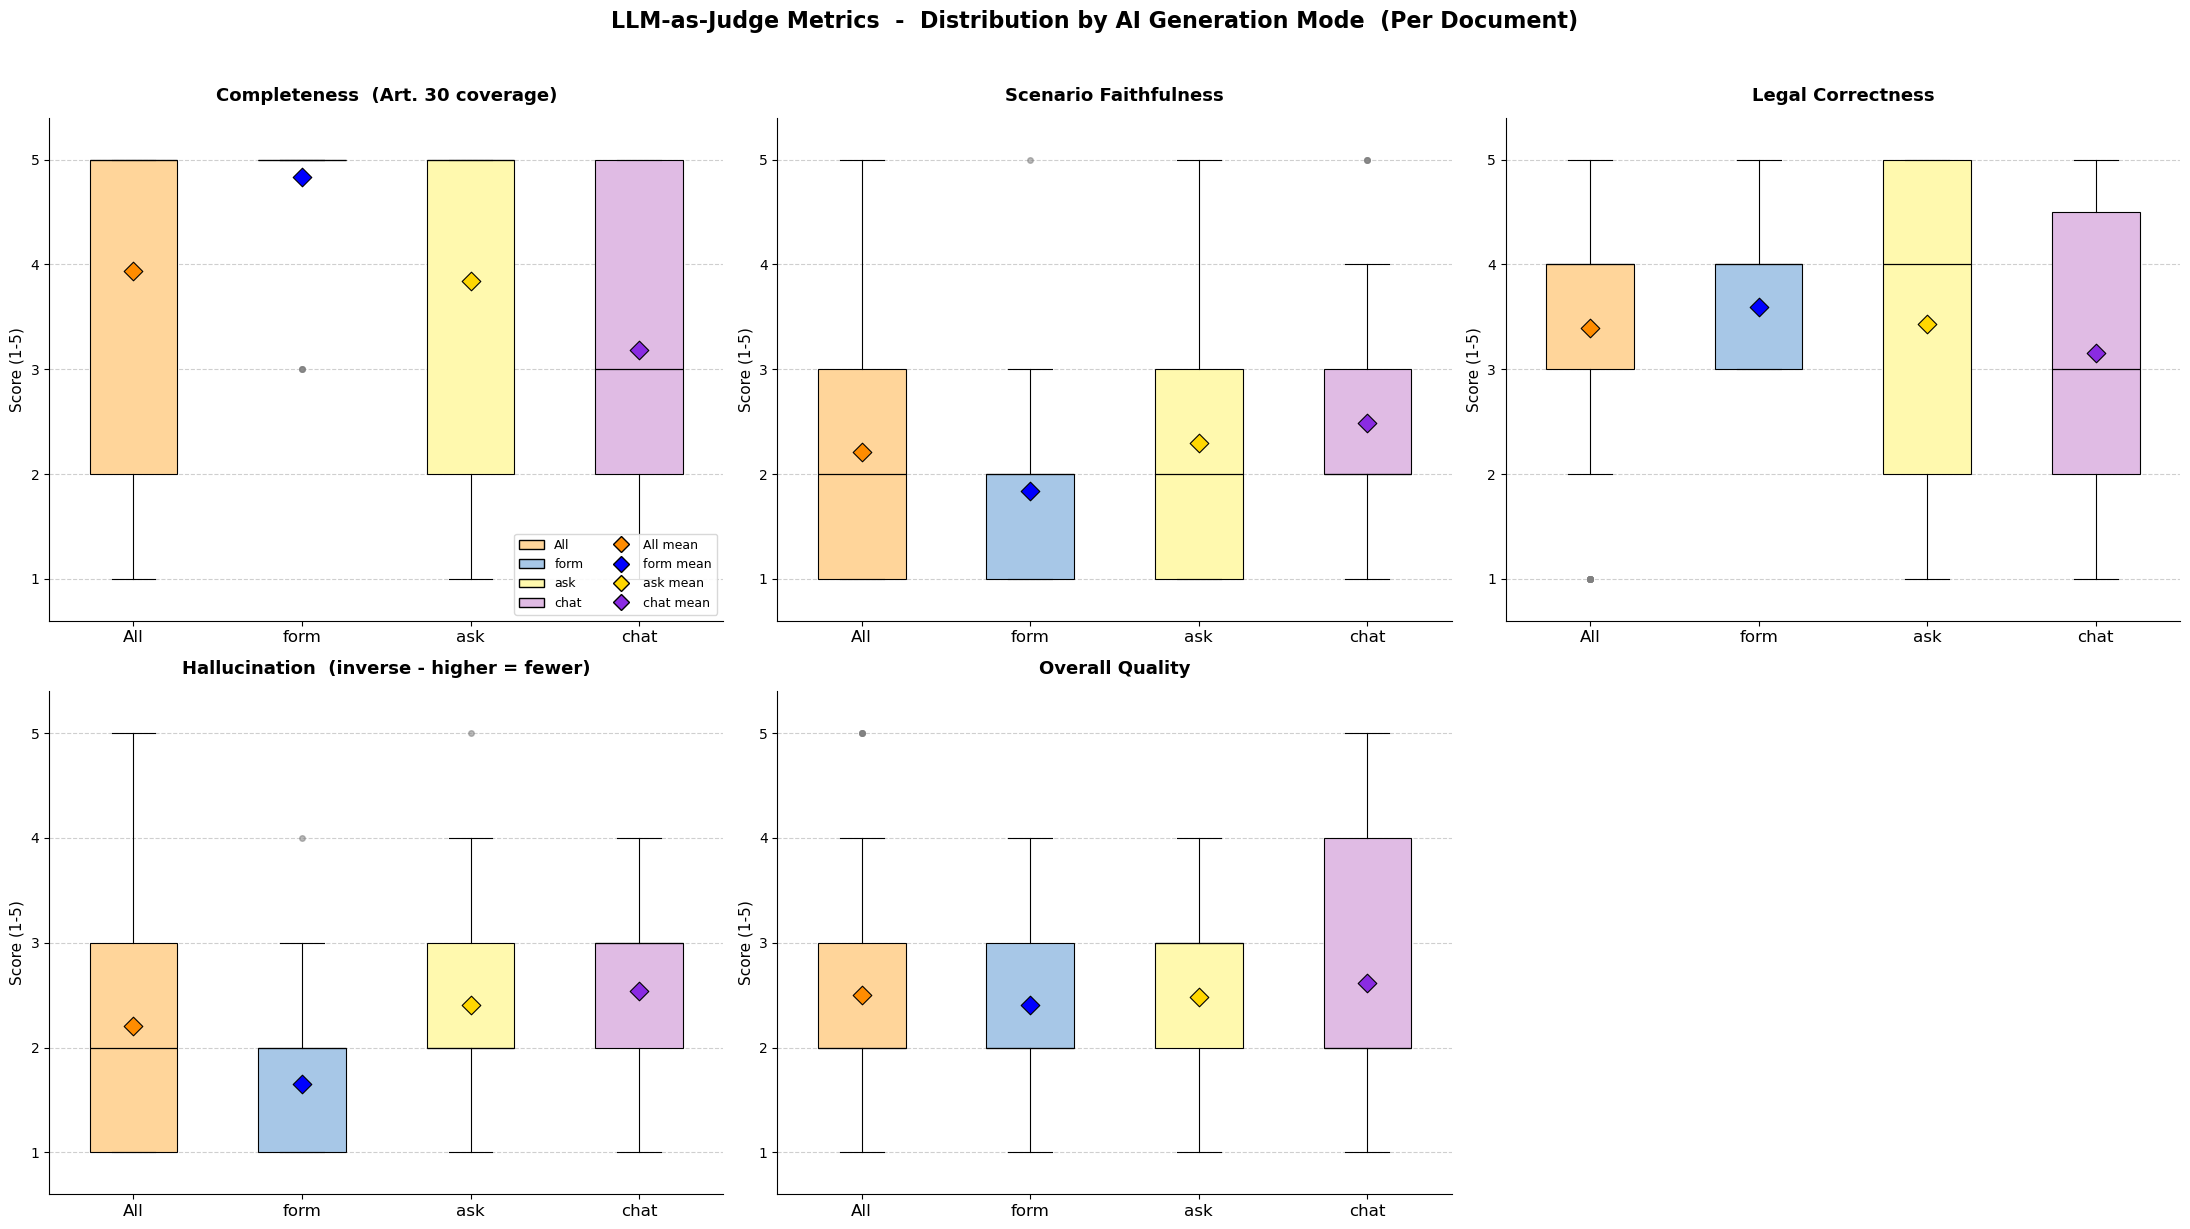

Saved -> /mnt/c/Dev/ropagen-bert/python/judge/output/judge_metrics_boxplot.png


In [6]:
# ── Per-metric judge boxplots (style matched to metrics notebook) ────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

JUDGE_METRIC_META = [
    ("completeness",          "Completeness  (Art. 30 coverage)"),
    ("scenario_faithfulness", "Scenario Faithfulness"),
    ("legal_correctness",     "Legal Correctness"),
    ("hallucination_inverse", "Hallucination  (inverse - higher = fewer)"),
    ("overall",               "Overall Quality"),
]

GROUPS      = ["All",     "form",    "ask",     "chat"]
BOX_COLORS  = ["#FFD59A", "#A7C7E7", "#FFF9AE", "#E0BBE4"]
MEAN_COLORS = ["#FF8C00", "#0000FF", "#FFD700", "#8A2BE2"]


def _scores(metric: str, mode_key: str) -> np.ndarray:
    df_m = judge_results[judge_results["metric"] == metric]
    if mode_key != "All":
        df_m = df_m[df_m["ai_mode"] == mode_key]
    return df_m["score"].dropna().values.astype(float)


def _draw_metric(ax, metric, title, add_legend=False):
    group_data = [_scores(metric, g) for g in GROUPS]

    bp = ax.boxplot(
        group_data,
        positions=range(len(GROUPS)),
        widths=0.52,
        patch_artist=True,
        showfliers=True,
        medianprops=dict(color="black", linewidth=0.9),
        whiskerprops=dict(color="black", linewidth=0.8),
        capprops=dict(color="black", linewidth=0.8),
        boxprops=dict(linewidth=0.8),
        flierprops=dict(marker="o", markerfacecolor="grey",
                        markeredgecolor="grey", markersize=4, alpha=0.55),
    )

    for patch, box_col in zip(bp["boxes"], BOX_COLORS):
        patch.set_facecolor(box_col)
        patch.set_edgecolor("black")

    for i, (data, mean_col) in enumerate(zip(group_data, MEAN_COLORS)):
        if len(data) == 0:
            continue
        ax.scatter(i, np.mean(data), marker="D", s=90,
                   color=mean_col, edgecolors="black", linewidths=0.8, zorder=6)

    ax.set_xticks(range(len(GROUPS)))
    ax.set_xticklabels(GROUPS, fontsize=12)

    # 1-5 Likert: fixed y range with a little headroom
    ax.set_ylim(0.6, 5.4)
    ax.set_yticks([1, 2, 3, 4, 5])

    ax.set_ylabel("Score (1-5)", fontsize=11)
    ax.set_title(title, fontsize=13, fontweight="bold", pad=12)
    ax.yaxis.grid(True, linestyle="--", linewidth=0.8, alpha=0.6)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)

    box_patches = [
        mpatches.Patch(facecolor=bc, edgecolor="black", label=g)
        for g, bc in zip(GROUPS, BOX_COLORS)
    ]
    mean_handles = [
        plt.Line2D([0], [0], marker="D", color="w",
                   markerfacecolor=mc, markeredgecolor="black",
                   markersize=8, label=f"{g} mean")
        for g, mc in zip(GROUPS, MEAN_COLORS)
    ]
    if add_legend:
        ax.legend(handles=box_patches + mean_handles, loc="lower right",
                  fontsize=9, ncol=2, framealpha=0.88, edgecolor="lightgrey")


# 2 x 3 grid, last slot unused (mirrors the NLP-metrics figure layout)
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
axes = axes.flatten()

for i, (metric, title) in enumerate(JUDGE_METRIC_META):
    _draw_metric(axes[i], metric, title, add_legend=(i == 0))

fig.delaxes(axes[5])

plt.suptitle(
    "LLM-as-Judge Metrics  -  Distribution by AI Generation Mode  (Per Document)",
    fontsize=16, fontweight="bold", y=1.02,
)
plt.tight_layout()
plt.savefig(BOXPLOT_PNG, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {BOXPLOT_PNG}")


In [7]:
# ── Step 5: Claude interpretation of judge scores ────────────────────────────
import json
import pandas as pd

INTERP_MD = OUT_DIR / "judge_interpretation.md"

# ── Load summary stats from disk (no recomputation) ──────────────────────────
summary_df = pd.read_csv(SUMMARY_CSV)
results_df = pd.read_csv(RESULTS_CSV)
docs_df    = pd.read_csv(DOCUMENTS_CSV)

pivot_mean   = summary_df.pivot(index="metric", columns="ai_mode", values="mean").reindex(JUDGE_METRICS)
pivot_median = summary_df.pivot(index="metric", columns="ai_mode", values="median").reindex(JUDGE_METRICS)
pivot_std    = summary_df.pivot(index="metric", columns="ai_mode", values="std").reindex(JUDGE_METRICS)

judge_summary_str  = "Judge metrics (1–5 Likert, higher = better).\n\n"
judge_summary_str += "Mean per mode:\n"   + pivot_mean.round(3).to_string()   + "\n\n"
judge_summary_str += "Median per mode:\n" + pivot_median.round(3).to_string() + "\n\n"
judge_summary_str += "Std per mode:\n"    + pivot_std.round(3).to_string()    + "\n"

# ── Best and worst document per mode ─────────────────────────────────────────
wide = results_df.pivot_table(
    index=["id", "ai_mode"], columns="metric", values="score"
).reset_index()
wide["total"] = wide[list(JUDGE_METRICS)].sum(axis=1)


def _pick(mode: str, best: bool) -> dict:
    m   = wide[wide["ai_mode"] == mode].sort_values(
        ["overall", "total"], ascending=[not best, not best]
    )
    row    = m.iloc[0]
    doc_id = int(row["id"])
    excerpt = (
        docs_df[docs_df["id"] == doc_id]["document"].iloc[0]
        .strip().lstrip("`").strip()[:400]
    )
    scores = {mn: int(row[mn]) for mn in JUDGE_METRICS}
    rats   = {
        mn: results_df[
            (results_df["id"] == doc_id) & (results_df["metric"] == mn)
        ]["rationale"].iloc[0]
        for mn in ["overall", "hallucination_inverse"]
    }
    return {"id": doc_id, "mode": mode, "label": "best" if best else "worst",
            "scores": scores, "rats": rats, "excerpt": excerpt}


examples = [_pick(m, b) for m in ["form", "ask", "chat"] for b in [False, True]]


def _fmt_examples(exs: list) -> str:
    parts = []
    for ex in exs:
        score_str = " | ".join(f"{k}={v}" for k, v in ex["scores"].items())
        parts.append(
            f"### {ex['mode'].upper()} — {ex['label'].capitalize()} (id={ex['id']})\n"
            f"Scores: {score_str}\n"
            f"Excerpt: {ex['excerpt']}\n"
            f"Rationale (overall): {ex['rats']['overall']}\n"
            f"Rationale (hallucination_inverse): {ex['rats']['hallucination_inverse']}"
        )
    return "\n\n---\n\n".join(parts)


examples_str = _fmt_examples(examples)

# ── Prompt ────────────────────────────────────────────────────────────────────
system_prompt = (
    "You are an expert in GDPR compliance assessment and LLM evaluation methodology. "
    "Your task is to write a structured, academically toned interpretive summary of "
    "LLM-as-judge scoring results for a study on AI-assisted ROPA document generation. "
    "Focus exclusively on what the judge scores reveal — do not include NLP metrics, "
    "survey data, or cross-layer triangulation. Be specific and cite scores."
)

user_prompt = f"""You have received LLM-as-judge scores for 113 ROPA documents generated by study participants across three AI interaction modes: Form (structured questionnaire), Ask (guided dialogue), and Chat (freeform conversation). The judge is Gemini 3.1 Pro Preview; it scored each document on five dimensions using a 1–5 Likert scale.

## Per-mode summary statistics

{judge_summary_str}

## Best and worst document per mode (outlier examples)

{examples_str}

---

Write a structured interpretive summary (~400–600 words) covering:

1. **Overall mode differences** — how do Form, Ask, and Chat compare across the five dimensions? What is the dominant pattern?
2. **Completeness vs. faithfulness trade-off** — describe the tension between structural coverage and scenario adherence, with specific scores.
3. **Hallucination profile** — which mode hallucinates most and least, and what does the hallucination_inverse score distribution suggest?
4. **Outlier examples** — what do the best and worst documents per mode illustrate about the limits and strengths of each interaction style?
5. **Within-mode variability** — note any modes with high standard deviation and what that implies.

Use section headers. Be precise — cite specific mean scores when making comparative claims. Do not speculate beyond what the judge data supports.
"""

# ── Call Claude Sonnet 4.6 via OpenRouter ────────────────────────────────────
interp_resp = client.chat.completions.create(
    model="anthropic/claude-sonnet-4-6",
    temperature=0.2,
    messages=[
        {"role": "system", "content": system_prompt},
        {"role": "user",   "content": user_prompt},
    ],
)
interp_text = interp_resp.choices[0].message.content

# ── Save and print ────────────────────────────────────────────────────────────
INTERP_MD.write_text(interp_text, encoding="utf-8")
print(f"Saved -> {INTERP_MD}\n")
print(interp_text)


Saved -> /mnt/c/Dev/ropagen-bert/python/judge/output/judge_interpretation.md

# Interpretive Summary of LLM-as-Judge Scores Across ROPA Generation Modes

## 1. Overall Mode Differences

Across the five evaluated dimensions, the three interaction modes — Form, Ask, and Chat — exhibit meaningfully distinct scoring profiles, with no single mode dominating uniformly. Form achieves the highest mean completeness (4.838) and legal correctness (3.595), suggesting that structured questionnaire-based interaction reliably elicits the requisite GDPR fields and legally appropriate framing. However, Form simultaneously records the lowest mean scores on scenario faithfulness (1.838) and hallucination_inverse (1.649), indicating that structural completeness is frequently purchased at the cost of factual fidelity to the provided scenario. Ask occupies a middle position on most dimensions, with a completeness mean of 3.838 and legal correctness of 3.432, while Chat scores lowest on completeness (3.179) 